# Analise 4 - Níveis de Dependência Digital em Diferentes Plataformas

## 1. Introdução
O uso das redes sociais pode variar bastante de acordo com a forma como o adolescente utiliza as plataformas disponíveis. Alguns jovens usam principalmente o Instagram, outros usam principalmente o TikTok, e há também aqueles que usam as duas redes sociais de forma combinada. Por isso, nesta análise, o foco não é tratar todas as categorias como se fossem plataformas isoladas, mas sim comparar as categorias de uso presentes na base.

A categoria `Both` representa o uso combinado de Instagram e TikTok. Já as categorias `Instagram` e `TikTok` indicam o uso principal de uma dessas plataformas. A partir disso, a análise observa se existem diferenças no nível de dependência digital entre esses grupos e se a média é uma métrica adequada para essa comparação.

## 2. Objetivo
Os objetivos principais desta seção são:
* Avaliar e comparar o nível médio de dependência digital (`addiction_level`) entre as categorias de uso das redes sociais (`platform_usage`).
* Verificar se a média é uma métrica aceitável para comparar essas categorias.
* Complementar a média com mediana, desvio padrão e quantidade de registros para evitar uma interpretação frágil dos dados.

## 3. Metodologia
Utilizaremos a mesma base de dados tratada para extrair os recortes por categoria de uso:
* `dados_limpos.csv`: Base consolidada com dados categóricos padronizados.

### 3.1 Carregamento e Pré-processamento dos Dados


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Garante que os gráficos apareçam no notebook
%matplotlib inline

# Carregando a base tratada
df = pd.read_csv('../../bases/processed/dados_limpos.csv')

## 4. Gráficos e Insights

### 4.1 Categorias de Uso das Redes Sociais vs Nível Médio de Dependência Digital
Nesta etapa, utilizamos um gráfico de barras para comparar o nível médio de dependência digital de acordo com a categoria de uso das redes sociais:
* **Eixo X (Categórico):** Categoria de uso das redes sociais (`platform_usage`)
* **Eixo Y (Contínuo):** Nível Médio de Dependência Digital (`addiction_level` de 1 a 10)

**Hipótese:** O uso combinado de Instagram e TikTok poderia apresentar uma média de dependência digital maior, porque representa o contato com mais de uma plataforma. No entanto, para verificar se a média é realmente uma boa métrica, também serão observadas a mediana, o desvio padrão e a quantidade de registros em cada grupo.


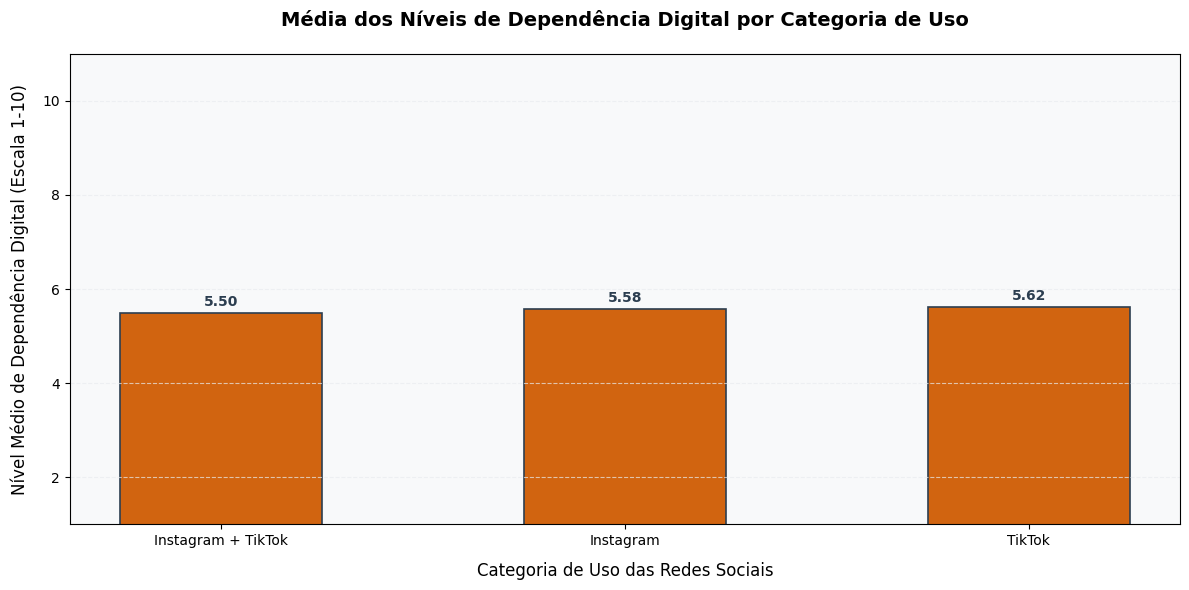

In [2]:
dados_agrupados = df.groupby('platform_usage')['addiction_level'].mean().reset_index()

# Ajuste apenas para melhorar a leitura do gráfico:
# "Both" representa o uso combinado de Instagram e TikTok.
dados_agrupados['categoria_uso'] = dados_agrupados['platform_usage'].replace({
    'Both': 'Instagram + TikTok'
})

# 2. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 3. Construção do Gráfico de Barras
barras = plt.bar(
    dados_agrupados['categoria_uso'], 
    dados_agrupados['addiction_level'], 
    color="#d16410",          
    edgecolor='#2c3e50',   
    linewidth=1.2,
    width=0.5                 
)

for barra in barras:    
    altura = barra.get_height()
    plt.annotate(
        f'{altura:.2f}',
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 3),        
        textcoords="offset points",
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold',
        color='#2c3e50'
    )

# 5. Customização de títulos e rótulos
plt.title('Média dos Níveis de Dependência Digital por Categoria de Uso', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Categoria de Uso das Redes Sociais', fontsize=12, labelpad=10)
plt.ylabel('Nível Médio de Dependência Digital (Escala 1-10)', fontsize=12, labelpad=10)

# Define o limite do eixo Y de 1 a 10
plt.ylim(1, 11)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 4.2 Verificação da Média como Métrica
Nesta etapa, a média será comparada com outras métricas descritivas. Isso é importante porque uma média pode esconder diferenças internas dentro de cada grupo. Se a mediana for igual entre os grupos e o desvio padrão for alto, a média sozinha pode não ser suficiente para sustentar uma conclusão forte.

As métricas analisadas são:
* **Média:** valor médio do nível de dependência digital.
* **Mediana:** valor central da distribuição.
* **Desvio padrão:** indica o quanto os valores variam dentro de cada grupo.
* **Quantidade:** mostra se os grupos possuem tamanhos parecidos.


In [ ]:
metricas_categoria = df.groupby('platform_usage')['addiction_level'].agg(
    media='mean',
    mediana='median',
    desvio_padrao='std',
    quantidade='count'
).reset_index()

# Ajuste apenas para melhorar a leitura da tabela:
# "Both" representa o uso combinado de Instagram e TikTok.
metricas_categoria['categoria_uso'] = metricas_categoria['platform_usage'].replace({
    'Both': 'Instagram + TikTok'
})

metricas_categoria = metricas_categoria[[
    'categoria_uso',
    'media',
    'mediana',
    'desvio_padrao',
    'quantidade'
]]

display(metricas_categoria)

diferenca_medias = metricas_categoria['media'].max() - metricas_categoria['media'].min()
desvio_medio = metricas_categoria['desvio_padrao'].mean()

print(f'Diferença entre a maior e a menor média: {diferenca_medias:.2f}')
print(f'Desvio padrão médio dos grupos: {desvio_medio:.2f}')

,categoria_uso,media,mediana,desvio_padrao,quantidade
0,Instagram + TikTok,5.496164,6.0,2.834650,391
1,Instagram,5.581509,6.0,2.810268,411
2,TikTok,5.615578,6.0,2.853335,398


Diferença entre a maior e a menor média: 0.12
Desvio padrão médio dos grupos: 2.83


#### **4.2.1 Conclusão**
Ao analisar o gráfico e a tabela de métricas, podemos apontar as seguintes conclusões sobre os níveis de dependência digital:

* **Maior Média de Dependência Digital:** A maior média foi registrada no grupo de **TikTok**, com **5.62** na escala de 1 a 10.
* **Menor Média Observada:** A menor média foi registrada no grupo de **Instagram + TikTok**, com **5.50**.
* **Comparação com Outras Métricas:** As métricas observadas foram:

    * **TikTok**: *média* 5.62, *mediana* 6, *desvio padrão* 2.85, n=398;
    * **Instagram**: *média* 5.58, *mediana* 6, *desvio padrão* 2.81, n=411;
    * **Instagram + TikTok**: *média* 5.50, *mediana* 6, *desvio padrão* 2.83, n=391.
* Ou seja, a mediana ficou igual entre as categorias, indicando que o centro da distribuição é muito parecido nos três grupos.

* **A Média é uma Métrica Aceitável?** A média é aceitável apenas como uma métrica descritiva inicial, porque `addiction_level` é uma variável numérica em escala de 1 a 10 e os grupos possuem quantidades parecidas de registros. Porém, ela **não é uma boa métrica para sustentar sozinha uma conclusão forte**, porque a diferença entre a maior e a menor média foi de apenas **0.12** ponto, enquanto o desvio padrão médio dos grupos foi de aproximadamente **2.83**. Ou seja, a variação dentro de cada grupo é muito maior do que a diferença entre as médias.
* **Validação:** A hipótese de que a categoria de uso das redes sociais gera grandes diferenças nos níveis de dependência digital **não foi confirmada de forma forte**. O gráfico mostra pequenas diferenças, mas a tabela indica que essas diferenças são muito discretas. Assim, a categoria de uso pode até ter alguma relação com a dependência digital, mas, nesta base, ela não parece explicar sozinha grandes variações no índice analisado.
